In [1]:
%matplotlib inline
import warnings
import time
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import brainstate
import braintools
import brainunit as u
import brainmass
from brainmass import objectives
from brainstate.nn import Param
brainstate.environ.set(dt=0.1 * u.ms)
brainstate.random.seed(0)


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


# Compose a Custom Objective

**Goal:** build the loss your fit actually needs — combine the
`brainmass.objectives` builders, write your own, and plug the result into
`brainmass.Fitter`.

An *objective* in `brainmass` is a small `callable(prediction, target) -> scalar`
that is `jit` / `grad` / `vmap`-safe and unit-aware. The builders in
`brainmass.objectives` return such callables; you compose them or write your own
with the same signature.


## The built-in toolkit

Every entry in `brainmass.objectives` is a *builder* that returns a loss/score
callable. They wrap `braintools.metric` — no metric maths is reimplemented.


In [2]:
import numpy as np
rng = np.random.default_rng(0)
pred = jnp.asarray(rng.standard_normal((200, 6)))    # (time, regions)
target = jnp.asarray(rng.standard_normal((200, 6)))

print("timeseries_rmse :", float(objectives.timeseries_rmse()(pred, target)))
print("fc_corr (score) :", float(objectives.fc_corr()(pred, target)))
print("fc_corr (loss)  :", float(objectives.fc_corr(as_loss=True)(pred, target)))
print("cosine_sim      :", float(objectives.cosine_sim()(pred, target)))
print("fcd (loss)      :", float(objectives.fcd(as_loss=True)(pred, target)))

timeseries_rmse : 1.433825135231018


fc_corr (score) : -0.19663743674755096
fc_corr (loss)  : 1.1966373920440674


cosine_sim      : -0.025183098390698433


fcd (loss)      : 0.5260788798332214


A few conventions worth knowing:

- **Score vs loss.** `fc_corr` / `cosine_sim` / `fcd` return a *score* to maximise
  by default; pass `as_loss=True` to get `1 - score`, a quantity to *minimise*.
  `timeseries_rmse` / `fc_rmse` are already losses.
- **Unit safety.** `timeseries_rmse` subtracts before stripping units, so mixing
  mV and Hz raises. FC / cosine objectives are scale-invariant and operate on
  magnitudes.
- **Identity is exact.** Every loss returns `0` (and every score `1`) when
  prediction equals target.


In [3]:
x = jnp.zeros((50, 4)) + jnp.asarray(rng.standard_normal((50, 4)))
print("rmse(x, x)    =", float(objectives.timeseries_rmse()(x, x)))
print("fc_corr(x, x) =", float(objectives.fc_corr()(x, x)))

rmse(x, x)    = 0.0


fc_corr(x, x) = 1.0


## Combine weighted objectives

`objectives.combine` sums `(weight, objective)` pairs into one callable — the
standard way to balance, say, a time-domain term against a connectivity term.


In [4]:
combined = objectives.combine(
    (1.0, objectives.timeseries_rmse()),
    (0.5, objectives.fc_corr(as_loss=True)),
)
print("combined loss:", float(combined(pred, target)))

# Sanity check the arithmetic on a controlled example:
a = jnp.zeros((10, 3))
check = objectives.combine(
    (2.0, objectives.timeseries_rmse()),
    (0.5, objectives.timeseries_rmse()),
)
print("(2.0 + 0.5) * 1.0 =", float(check(a + 1.0, a)))

combined loss: 2.0321438312530518


(2.0 + 0.5) * 1.0 = 2.5


## Write your own objective

A custom objective is any function with the `(prediction, target) -> scalar`
signature, built from `jax.numpy` so it stays differentiable. Two rules:

1. Reduce to a **scalar** (a gradient optimiser needs one number).
2. Strip units with `u.get_magnitude` only where the quantity is scale-free; keep
   them through a subtraction so unit mismatches are caught.

Here is a **spectral-peak** objective: match the dominant oscillation frequency
of each region. It reuses `braintools.metric.power_spectral_density` rather than
hand-rolling an FFT. (`power_spectral_density(signal, dt_ms)` returns frequencies
in cycles per `dt` unit; comparing two peaks in the *same* units is all we need.)


In [5]:
def peak_frequency_mse(dt_ms=1.0):
    """Loss matching the dominant spectral peak of each region."""
    def loss(prediction, target):
        def peak_freqs(sig):
            sig = u.get_magnitude(sig)
            def one(col):
                freqs, psd = braintools.metric.power_spectral_density(col, dt_ms)
                return freqs[jnp.argmax(psd)]
            return jax.vmap(one, in_axes=1)(sig)  # (regions,)
        diff = peak_freqs(prediction) - peak_freqs(target)
        return jnp.mean(diff ** 2)
    return loss

# A 4-region bank of sinusoids at well-separated frequencies, sampled at 1 ms.
samples = np.arange(1000)
dt_s = 1e-3  # 1 ms sampling
rng2 = np.random.default_rng(1)
def sine_bank(freqs_hz):
    cols = [np.sin(2 * np.pi * f * samples * dt_s) + 0.05 * rng2.standard_normal(1000)
            for f in freqs_hz]
    return jnp.asarray(np.stack(cols, axis=1))

pred_sig = sine_bank([5, 10, 20, 30])
fast_sig = sine_bank([8, 16, 28, 40])

spec_loss = peak_frequency_mse(dt_ms=1.0)
print("peak-freq loss (pred vs fast):", float(spec_loss(pred_sig, fast_sig)))
print("peak-freq loss (pred vs pred):", float(spec_loss(pred_sig, pred_sig)))

peak-freq loss (pred vs fast): 6.103515625e-05
peak-freq loss (pred vs pred): 0.0


Custom objectives compose with the built-ins through `combine`, exactly like
the library ones — they share the same signature. Here a connectivity term and
the spectral term are balanced into one loss (both inputs have ≥2 regions, so
`fc_corr` is well-defined).


In [6]:
mixed = objectives.combine(
    (1.0, objectives.fc_corr(as_loss=True)),
    (0.1, peak_frequency_mse(dt_ms=1.0)),
)
print("mixed FC + spectral loss:", float(mixed(pred_sig, fast_sig)))

mixed FC + spectral loss: 1.7818667888641357


## Plug an objective into `Fitter`

`brainmass.Fitter` accepts an objective two ways:

- **`objective=`** — a `(prediction, target)` callable; the Fitter builds the loss
  as `objective(predict(model), target) + model.reg_loss()`, and you supply
  `predict` (a `Simulator` closure) and the `target`.
- **`loss_fn=`** — a full `loss_fn(model) -> (scalar, aux)` that you own entirely,
  for losses against a *derived scalar summary* (the right choice for oscillators,
  where a point-by-point `timeseries_rmse` is phase-degenerate).

Here we fit the Hopf bifurcation parameter `a` so the settled amplitude matches a
target, using a custom scalar objective inside `loss_fn`.


In [7]:
def amplitude_loss(target_amp):
    def loss(prediction):
        x = u.get_magnitude(prediction)
        amp = jnp.sqrt(jnp.mean(x ** 2)) * jnp.sqrt(2.0)
        return (amp - target_amp) ** 2, amp
    return loss

target_amp = 1.2
obj = amplitude_loss(target_amp)

# Mark `a` trainable with a Param; a plain Param(fit=True) lives in physical space.
node = brainmass.HopfStep(in_size=1, a=Param(0.1, fit=True), w=0.3,
                          init_x=braintools.init.Constant(0.5))

def loss_fn(m):
    res = brainmass.Simulator(m, dt=0.1 * u.ms).run(
        150 * u.ms, monitors=['x'], transient=50 * u.ms)
    return obj(res['x'])   # (scalar loss, amplitude aux)

fitter = brainmass.Fitter(node, braintools.optim.Adam(lr=0.05), loss_fn=loss_fn)
result = fitter.fit(n_steps=40)
print(f"target amplitude : {target_amp}")
print(f"fitted a         : {result.best_params['a']:.3f}")
print(f"best loss        : {result.best_loss:.2e}")

target amplitude : 1.2
fitted a         : 1.232
best loss        : 8.41e-03


The fit drives `a` from `0.1` toward the value whose limit cycle has amplitude
`1.2`. Plot the loss curve from `result.history`:


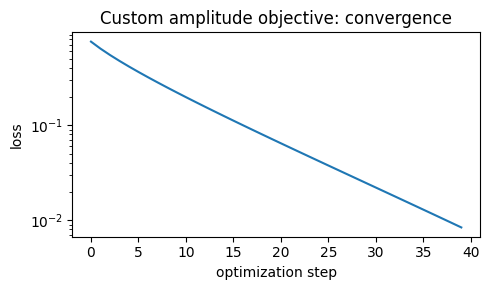

In [8]:
hist = np.asarray(result.history)
fig, ax = plt.subplots(figsize=(5, 3))
ax.semilogy(hist)
ax.set_xlabel('optimization step')
ax.set_ylabel('loss')
ax.set_title('Custom amplitude objective: convergence')
fig.tight_layout()
plt.show()

## Using `objective=` with a `predict` closure

When the loss *is* a `brainmass.objectives` builder over the trajectory (e.g. an
FC fit), pass it via `objective=` and supply `predict` + `target`. The Fitter
handles the `reg_loss` and the optimisation loop.


In [9]:
# 3-region drive so FC is non-degenerate.
conn = brainmass.datasets.load_dataset('example_connectome')
W3, D3 = conn.weights[:3, :3], conn.distances[:3, :3]
brainstate.environ.set(dt=0.1 * u.ms)

def make_net(k):
    base = brainmass.HopfStep(in_size=3, a=0.3, w=0.3,
                              init_x=braintools.init.Constant(0.3))
    return brainmass.Network(base, conn=W3, distance=D3, speed=10 * u.mm / u.ms,
                             coupling='diffusive', coupled_var='x', k=k)

def simulate(net):
    res = brainmass.Simulator(net, dt=0.1 * u.ms).run(
        400 * u.ms, monitors=lambda m: m.node.x.value, transient=100 * u.ms)
    return res['output']

# Target FC from a "ground-truth" coupling of 1.0.
target_signal = simulate(make_net(1.0))

# Fit k with a trainable Param, FC-correlation objective.
net = make_net(Param(0.3, fit=True))
fitter = brainmass.Fitter(
    net, braintools.optim.Adam(lr=0.05),
    objective=objectives.fc_corr(as_loss=True),
    predict=simulate,
)
res = fitter.fit(target=target_signal, n_steps=30)
print(f"fitted coupling k : {res.best_params['coupling.k']:.3f}  (true 1.0)")
print(f"best FC loss      : {res.best_loss:.4f}")

fitted coupling k : 0.456  (true 1.0)
best FC loss      : 0.0002


## Recap

- Objectives are `(prediction, target) -> scalar` callables; the builders in
  `brainmass.objectives` produce them, and `combine` weights them together.
- Write your own with `jax.numpy`, reduce to a scalar, and keep units through
  subtractions.
- Feed the Fitter a derived-scalar `loss_fn=` (oscillator amplitude / spectrum) or
  an `objective=` + `predict=` (FC / FCD over the trajectory).

## Next steps

- {doc}`/tutorials/06_fitting_with_gradients` — the full gradient-fitting workflow.
- {doc}`/tutorials/07_gradient_free_fitting` — the same objective, derivative-free.
- {doc}`/howto/analyze_results` — the metrics these objectives are built on.
- {doc}`/reference/orchestration` — the `Fitter` / `objectives` API.
